In [18]:
from hydra import initialize, compose
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.patches import Patch
import re
from rdkit import Chem
from rdkit.Chem import AllChem
from collections import defaultdict, Counter
from itertools import product
from ergochemics.draw import draw_molecule, draw_reaction
from IPython.display import SVG

with initialize(version_base=None, config_path="../configs/filepaths"):
    cfg = compose(config_name="filepaths")

def find_between_rules(s):
    match = re.search(r'_rules_(.+?)_rules_', s)
    return match.group(1) if match else None

def check_for_kr_match(lhs: Counter, rhs: Counter, kr_counts: list[tuple[Counter, Counter]]):
    for kr_lhs, kr_rhs in kr_counts:
        possible = True
        for lsmi, lcount in lhs.items():
            if kr_lhs.get(lsmi, 0) != lcount:
                possible = False
                break
        if not possible:
            continue
        for rsmi, rcount in rhs.items():
            if kr_rhs.get(rsmi, 0) != rcount:
                possible = False
                break
        if possible:
            return True
    return False

In [169]:
cutoff_date = 2015
unbalanced_rules = ['retrobiocat', 'evodex', "mechinferred_dt_932", "mechinferred_dt_069", "mechinferred_dt_021"]
pub = pl.read_parquet(Path(cfg.raw_data) / "rxn_pub_dates.parquet")
pub = pub.explode("publication_dates")
pub = pub.group_by("id").agg(
    pl.col("publication_dates").min(),
    pl.col("smarts").first()
).filter(pl.col("publication_dates") >= cutoff_date).rename({"publication_dates": "pub_date"})
tot_pub_rxns = pub.shape[0]
print(f"Total reactions with publication date >= {cutoff_date}: {tot_pub_rxns:,}")
pub.head()

Total reactions with publication date >= 2015: 4,466


id,pub_date,smarts
str,i32,str
"""682b616e97c94a7ccbcd3206cb8521…",2015,"""CCCCCCCCCCCCC=CC1OP(=O)(O)OCC1…"
"""cbd10264a15f8a1649015e15bf9fc9…",2016,"""*OC1C(COP(*)(=O)O)OC(n2cc(C)c(…"
"""c5770bf7f157d99992542af7066fa3…",2018,"""Clc1ccc(COC(Cn2ccnc2)c2ccc(Cl)…"
"""7e8df8bc1af9426725ccc683277b09…",2023,"""*NC(CC(=O)NC1OC(COC2OC(C)C(O)C…"
"""a7575e255b5a809e42a228349c0e3d…",2017,"""*NC(CC(=O)NC1OC(COC2OC(C)C(O)C…"


In [170]:
# max_rcts = 6
# max_pdts = 7
# pub = pub.with_columns(
#     pl.col("smarts").str.split(">>").list.get(0).str.split(".").list.len().alias("n_reactants"),
#     pl.col("smarts").str.split(">>").list.get(1).str.split(".").list.len().alias("n_products")
# ).filter(
#     pl.col("n_reactants") <= max_rcts,
#     pl.col("n_products") <= max_pdts
# ).select("id", "smarts")
# pub.head()

In [171]:
# pub.write_parquet("/home/stef/quest_data/enz_rxn_data/data/processed/pathway/known_reactions_after_2015.parquet")

In [172]:
# kr_counts = []
# for row in pub.iter_rows(named=True):
#     lhs, rhs = [set(side.split(".")) for side in row["smarts"].split(">>")]
#     kr_counts.append((Counter(lhs), Counter(rhs)))

In [176]:
metrics = []
for fn in (Path(cfg.interim_data) / "std_pickaxe_rxns").glob("*.parquet"):
    _name = find_between_rules(fn.stem)
    is_unbalanced = any(elt in _name for elt in unbalanced_rules)

    if is_unbalanced:
        print(_name)
        suffix = f"_before_{cutoff_date}" if "retrobiocat" not in _name else ""
        maps = pl.read_parquet(
            Path(cfg.raw_data) / "mappings" / f"mappings_known_reactions_after_2015_x_{_name}_rules{suffix}.parquet"
        ).unique('rxn_id')
    else:

        suffix = "_direct_mcsa_only" if "direct_mcsa_only" in fn.stem else ""

        maps = pl.read_parquet(
            Path(cfg.raw_data) / "mappings" / f"mapped_known_reactions_x_{_name}_rules_before_{cutoff_date}{suffix}.parquet"
        )
        _name = f"{_name}{suffix}"

    pred = pl.read_parquet(fn)
    
    _n_pub_recovered = maps.join(pub, left_on="rxn_id", right_on="id", how="inner").shape[0]

    metrics.append(
        {
            "name": _name,
            "num_rxns": len(pred),
            "num_unique_rxns": pred["std_rxn"].n_unique(),
            "num_pub_rxns": _n_pub_recovered,
            "frac_pub_rxns": _n_pub_recovered / tot_pub_rxns,
            "fn": fn,
        }
    )

metrics.append(
    {
        "name": "rc_plus_0",
        "num_rxns": 7666721,
        "num_unique_rxns": 7666721,
        "num_pub_rxns": 2690,
        "frac_pub_rxns": 2690 / tot_pub_rxns,
         "fn": None,
    }
)

metrics.append(
    {
        "name": "mechinferred_dt_059_direct_mcsa_only",
        "num_rxns": 47_327,
        "num_unique_rxns": 47_327,
        "num_pub_rxns": 1_183,
        "frac_pub_rxns": 1_183 / tot_pub_rxns,
         "fn": None,
    }
)

metrics.append(
    {
        "name": "mechinferred_dt_035_direct_mcsa_only",
        "num_rxns": 40_109,
        "num_unique_rxns": 40_109,
        "num_pub_rxns": 780,
        "frac_pub_rxns": 780 / tot_pub_rxns,
         "fn": None,
    }
)

metrics = pl.DataFrame(metrics)
metrics.head()

evodex_Dm
mechinferred_dt_932
evodex_Cm
mechinferred_dt_069
mechinferred_dt_021
evodex_Em
retrobiocat


name,num_rxns,num_unique_rxns,num_pub_rxns,frac_pub_rxns,fn
str,i64,i64,i64,f64,object
"""rc_plus_2""",73707,73702,1612,0.360949,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_rc_plus_2_rules_before_2015_w_coreactants_aplusb_True.parquet
"""evodex_Dm""",76434,76434,2405,0.538513,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_evodex_Dm_rules_before_2015_w_coreactants_aplusb_True.parquet
"""rc_plus_1""",132439,131469,2048,0.458576,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_rc_plus_1_rules_before_2015_w_coreactants_aplusb_True.parquet
"""mechinferred_dt_961_direct_mcs…",750533,747874,2518,0.563815,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_961_rules_before_2015_direct_mcsa_only_w_coreactants_aplusb_True.parquet
"""rc_plus_3""",57791,57789,1208,0.270488,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_rc_plus_3_rules_before_2015_w_coreactants_aplusb_True.parquet


In [175]:
display(metrics.filter(pl.col("name").str.contains("evodex") | pl.col("name").str.contains("mech")).sort("frac_pub_rxns", descending=True).head(10))

name,num_rxns,num_unique_rxns,num_pub_rxns,frac_pub_rxns,fn
str,i64,i64,i64,f64,object
"""mechinferred_dt_932""",726073,723410,2519,0.564039,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_932_rules_before_2015_w_coreactants_aplusb_True.parquet
"""mechinferred_dt_961_direct_mcs…",750533,747874,2518,0.563815,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_961_rules_before_2015_direct_mcsa_only_w_coreactants_aplusb_True.parquet
"""evodex_Cm""",83518,83518,2423,0.542544,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_evodex_Cm_rules_before_2015_w_coreactants_aplusb_True.parquet
"""evodex_Dm""",76434,76434,2405,0.538513,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_evodex_Dm_rules_before_2015_w_coreactants_aplusb_True.parquet
"""evodex_Em""",60904,60904,2348,0.52575,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_evodex_Em_rules_before_2015_w_coreactants_aplusb_True.parquet
"""mechinferred_dt_069""",161821,161815,2238,0.50112,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_069_rules_before_2015_w_coreactants_aplusb_True.parquet
"""mechinferred_dt_244_direct_mcs…",157992,157986,2231,0.499552,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_244_rules_before_2015_direct_mcsa_only_w_coreactants_aplusb_True.parquet
"""mechinferred_dt_021""",81059,81052,1902,0.425884,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_021_rules_before_2015_w_coreactants_aplusb_True.parquet
"""mechinferred_dt_106_direct_mcs…",69329,69309,1722,0.38558,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_106_rules_before_2015_direct_mcsa_only_w_coreactants_aplusb_True.parquet


In [128]:
pred = pl.read_parquet(fn)
recovered = maps.join(pub, left_on="rxn_id", right_on="id", how="inner")

In [131]:
n = 0
ct_matches = set()
non_ct_matches = set()
for row in pred.iter_rows(named=True):
    lhs, rhs = [set(side.split(".")) for side in row["std_rxn"].split(">>")]
    does_match = check_for_kr_match(Counter(lhs), Counter(rhs), kr_counts)
    if does_match:
        ct_matches.add(row['id'])
        n += 1

    else:
        non_ct_matches.add(row['id'])
id_matches = set(recovered['rxn_id'].to_list())

In [132]:
ct_matches - id_matches

{'113f57e58dd050a5decbc58d39124ae2964ef1fe',
 '6272c70f43db47406b611440b9eba5e07745d5e8',
 '9dbf87183ddb9c0f768585b5db7e8c191539c5dc',
 'c75dc9bb55c40beff0842afe4e5d1a14d60fe2f1',
 'f64ab29d7d0215e1a6939659d73cff008ce1492e'}

In [133]:
id_matches - ct_matches

{'...'}

In [138]:
pub.filter(pl.col("id") == '00781565746ab4ce5cb9819c5577d694698cd2df').row(0)

('00781565746ab4ce5cb9819c5577d694698cd2df',
 2022,
 'CCCCCC=CCC=CCC=CCC=CCCCC(=O)OC(CO)COP(=O)(O)OCC[N+](C)(C)C.CCCCCCCCCCCCCCCCCC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O>>CC(C)(COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O)C(O)C(=O)NCCC(=O)NCCS.CCCCCC=CCC=CCC=CCC=CCCCC(=O)OC(COC(=O)CCCCCCCCCCCCCCCCC)COP(=O)(O)OCC[N+](C)(C)C')

{'id': '8b1222f8f82e95cdfdd89ff4214c96852bdbdfb5',
 'am_rxn': '[NH3:1].[NH2:2][CH:3]([CH2:4][CH2:5][S:6][CH2:7][CH:8]1[O:9][CH:10]([n:11]2[cH:12][n:13][c:14]3[c:15]([OH:16])[n:17][cH:18][n:19][c:20]32)[CH:21]([OH:22])[CH:23]1[OH:24])[C:25](=[O:26])[OH:27]>>[OH2:16].[NH2:1][c:15]1[n:17][cH:18][n:19][c:20]2[c:14]1[n:13][cH:12][n:11]2[CH:10]1[O:9][CH:8]([CH2:7][S:6][CH2:5][CH2:4][CH:3]([NH2:2])[C:25](=[O:26])[OH:27])[CH:23]([OH:24])[CH:21]1[OH:22]',
 'std_rxn': 'N.NC(CCSCC1OC(n2cnc3c(O)ncnc32)C(O)C1O)C(=O)O>>O.Nc1ncnc2c1ncn2C1OC(CSCCC(N)C(=O)O)C(O)C1O'}

In [124]:
row['id'] in recovered['rxn_id'].to_list()

False

In [122]:
recovered.filter(pl.col("rxn_id") == '8b1222f8f82e95cdfdd89ff4214c96852bdbdfb5')

rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id,pub_date,smarts_right
str,str,str,str,str,i64,i32,str


In [41]:
i = 0

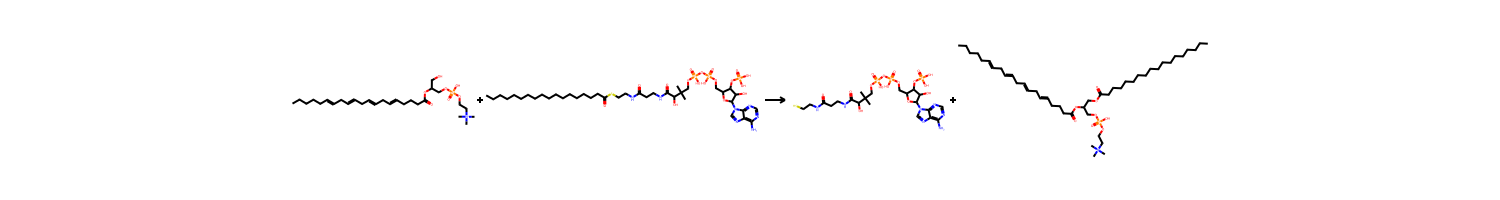

In [139]:
i+=1
SVG(draw_reaction('CCCCCC=CCC=CCC=CCC=CCCCC(=O)OC(CO)COP(=O)(O)OCC[N+](C)(C)C.CCCCCCCCCCCCCCCCCC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O>>CC(C)(COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O)C(O)C(=O)NCCC(=O)NCCS.CCCCCC=CCC=CCC=CCC=CCCCC(=O)OC(COC(=O)CCCCCCCCCCCCCCCCC)COP(=O)(O)OCC[N+](C)(C)C'))

In [25]:
metrics.filter(pl.col("name") == "mechinferred_dt_932")

name,num_rxns,num_unique_rxns,num_pub_rxns,frac_pub_rxns,fn
str,i64,i64,i64,f64,object
"""mechinferred_dt_932""",726073,723410,2519,0.564039,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_932_rules_before_2015_w_coreactants_aplusb_True.parquet


In [26]:
2519/726073

0.0034693481233980606

In [38]:
Rs = [0, 1, 2, 3, 4]
dts = ['932', '069', '021', '009', '005']
dts_dmo = ['961', '244', '106', '059', '035']
others = ['mechinformed', 'rdchiral', 'imt', "evodex_Cm", "evodex_Dm", "evodex_Em"]
mechinferred_template_sizes = defaultdict(list)
rcr_template_sizes = defaultdict(list)
dmo_template_sizes = defaultdict(list)
bad_rules = {'rcr': set(), 'mechinferred': set()}
rcr_rules = []
other_rules = []
other_template_sizes = defaultdict(list)

for dt in dts:
    df = pl.read_csv(
        Path(cfg.rules) / f"mechinferred_dt_{dt}_rules_before_{cutoff_date}.csv",
    )
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        mechinferred_template_sizes[dt].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for dt in dts_dmo:
    df = pl.read_csv(
        Path(cfg.rules) / f"mechinferred_dt_{dt}_rules_before_{cutoff_date}_direct_mcsa_only.csv",
    )
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        dmo_template_sizes[dt].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for R in Rs:
    if R == 0:
        df = pl.read_csv(
            Path(cfg.rules) / f"rc_plus_0_rules_before_{cutoff_date}.csv",
        )
    else:
        df = pl.read_csv(
            Path(cfg.rules) / f"rc_plus_{R}_rules_before_{cutoff_date}.csv",
        )
    rcr_rules.append(df)
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        rcr_template_sizes[R].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for other in others:
    if other == 'imt':
        df = pl.read_csv(
            Path(cfg.rules) / f"imt_rules_before_{cutoff_date}.csv",
        )
    else:
        df = pl.read_csv(
            source=Path(cfg.rules) / f"{other}_rules_before_{cutoff_date}.csv",
            ignore_errors=True,
        )
    other_rules.append(df)
    for row in df.iter_rows(named=True):
            sma = row["smarts"]
            rxn = AllChem.ReactionFromSmarts(sma)
            other_template_sizes[other].append(
                sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
            )

median_template_size = {}

for name in metrics["name"].unique().to_list():
    vals = None

    if name.startswith("mechinferred_dt_") and "direct_mcsa_only" not in name:
        dt = name.split("_")[-1]
        vals = mechinferred_template_sizes.get(dt, [])
    elif name.startswith("rc_plus_"):
        R = int(name.split("_")[-1])
        vals = rcr_template_sizes.get(R, [])
    elif name.startswith("mechinferred_dt_") and "direct_mcsa_only" in name:
        dt = name.split("_")[2]
        vals = dmo_template_sizes.get(dt, [])
    else:
        vals = other_template_sizes.get(name, [])

    median_template_size[name] = pl.Series(vals).median() if vals else None

median_template_size


{'rc_plus_1': 8.0,
 'rdchiral': 10.0,
 'mechinferred_dt_021': 30.0,
 'mechinferred_dt_961_direct_mcsa_only': 4.0,
 'evodex_Dm': 10.0,
 'rc_plus_2': 13.0,
 'mechinferred_dt_005': 40.0,
 'evodex_Cm': 9.0,
 'rc_plus_3': 17.0,
 'rc_plus_4': 21.0,
 'mechinferred_dt_932': 4.0,
 'imt': 3.0,
 'evodex_Em': 11.0,
 'retrobiocat': None,
 'mechinformed': 7.0,
 'mechinferred_dt_106_direct_mcsa_only': 34.0,
 'mechinferred_dt_009': 34.0,
 'mechinferred_dt_244_direct_mcsa_only': 19.0,
 'mechinferred_dt_069': 18.0,
 'rc_plus_0': 5.0,
 'mechinferred_dt_059_direct_mcsa_only': 38.0,
 'mechinferred_dt_035_direct_mcsa_only': 49.0}

In [39]:
# Plot cfg

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.titlesize": 16,
})

exp_labels = {
    'mechinformed': "Distilled",
    'mechinferred_dt_932': "Learned >0.932",
    'mechinferred_dt_069': "Learned >0.069",
    'mechinferred_dt_021': "Learned >0.021",
    'mechinferred_dt_009': "Learned >0.009",
    'mechinferred_dt_005': "Learned >0.005",
    'mechinferred_dt_961_direct_mcsa_only': "Learned >0.961 (direct MCSA only)",
    'mechinferred_dt_244_direct_mcsa_only': "Learned >0.244 (direct MCSA only)",
    'mechinferred_dt_106_direct_mcsa_only': "Learned >0.106 (direct MCSA only)",
    'mechinferred_datat_059_direct_mcsa_only': "Learned >0.059 (direct MCSA only)",
    'mechinferred_dt_035_direct_mcsa_only': "Learned >0.035 (direct MCSA only)",
    'rc_plus_0': "RC + 0",
    'rc_plus_1': "RC + 1",
    'rc_plus_2': "RC + 2",
    'rc_plus_3': "RC + 3",
    'rc_plus_4': "RC + 4",
    'imt': "Pathway-level clustering",
    'rdchiral': "RDChiral",
    "retrobiocat": "RetroBioCat",
    "evodex_Cm": "EVODEX Cm",
    "evodex_Dm": "EVODEX Dm",
    "evodex_Em": "EVODEX Em"
}

colors = {
    'mechinformed': matplotlib.colors.to_rgba("green"),
    'mechinferred_dt_932': matplotlib.colors.to_rgba("purple", alpha=0.3),
    'mechinferred_dt_069': matplotlib.colors.to_rgba("purple", alpha=0.45),
    'mechinferred_dt_021': matplotlib.colors.to_rgba("purple", alpha=0.6),
    'mechinferred_dt_009': matplotlib.colors.to_rgba("purple", alpha=0.85),
    'mechinferred_dt_005': matplotlib.colors.to_rgba("purple", alpha=1.0),
    'mechinferred_dt_961_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=0.3),
    'mechinferred_dt_244_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=0.45),
    'mechinferred_dt_106_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=0.6),
    'mechinferred_datat_059_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=0.85),
    'mechinferred_dt_035_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=1.0),
    'rc_plus_0': matplotlib.colors.to_rgba("black", alpha=0.3),
    'rc_plus_1': matplotlib.colors.to_rgba("black", alpha=0.45),
    'rc_plus_2': matplotlib.colors.to_rgba("black", alpha=0.6),
    'rc_plus_3': matplotlib.colors.to_rgba("black", alpha=0.85),
    'rc_plus_4': matplotlib.colors.to_rgba("black", alpha=1.0),
    'imt': matplotlib.colors.to_rgba("darkorange"),
    'rdchiral': matplotlib.colors.to_rgba("blue"),
    "retrobiocat": matplotlib.colors.to_rgba("cyan"),
    "evodex_Cm": matplotlib.colors.to_rgba("red", alpha=0.3),
    "evodex_Dm": matplotlib.colors.to_rgba("red", alpha=0.6),
    "evodex_Em": matplotlib.colors.to_rgba("red", alpha=0.9),
}

exp_names = list(exp_labels.keys())

legend_elements = [
    Patch(facecolor=col, edgecolor='w', label=exp_labels[name])
    for name, col in colors.items()
]

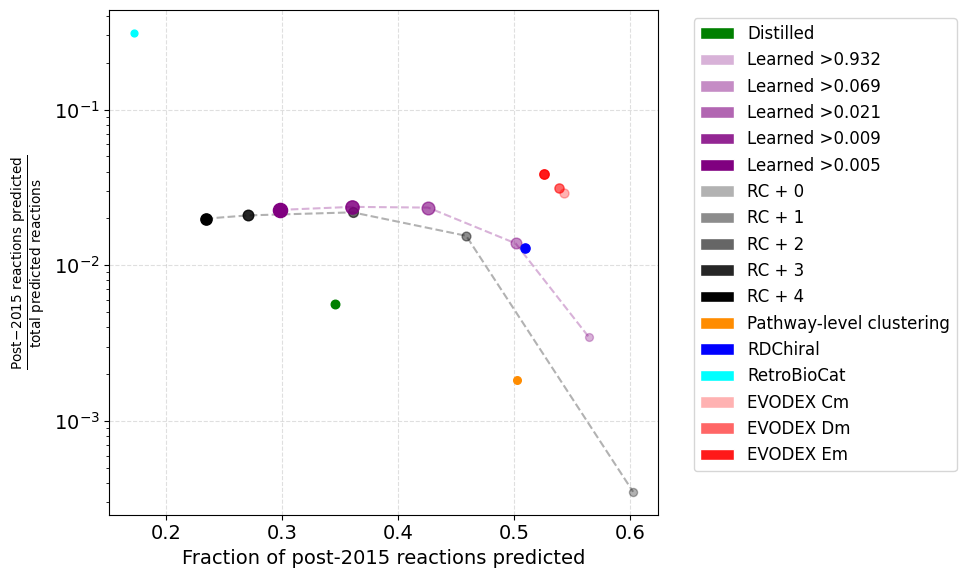

In [113]:
fig, ax = plt.subplots(figsize=(10, 6))
dot_slope = 2
dot_intercept = 24

legend_elements = [
    Patch(facecolor=col, edgecolor='w', label=exp_labels[name])
    for name, col in colors.items()
    if "direct_mcsa_only" not in name
]

# collect grouped points for connecting lines
mechinferred_data = []
rcr_data = []

for row in metrics.iter_rows(named=True):
    name = row["name"]
    if "direct_mcsa_only" in name:
        continue
    
    if name not in exp_labels:
        continue

    x = row["frac_pub_rxns"]
    y = row["num_pub_rxns"] / row["num_rxns"]

    template_size = median_template_size.get(name)
    marker_size = (
        dot_slope * template_size + dot_intercept
        if template_size is not None
        else dot_intercept
    )

    if name.startswith("mechinferred_dt_"):
        mechinferred_data.append((x, y))
    elif name.startswith("rc_plus_"):
        rcr_data.append((x, y))

    ax.scatter(
        x,
        y,
        color=colors[name],
        s=marker_size,
        label=exp_labels[name],
        zorder=3,
    )

# connect purple dots (mechinferred)
if mechinferred_data:
    mechinferred_data = sorted(mechinferred_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in mechinferred_data],
        [p[1] for p in mechinferred_data],
        color="purple",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

# connect black dots (rc_plus)
if rcr_data:
    rcr_data = sorted(rcr_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in rcr_data],
        [p[1] for p in rcr_data],
        color="black",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

ax.set_xlabel(f"Fraction of post-{cutoff_date} reactions predicted")
ax.set_ylabel(
    rf"$\frac{{\mathrm{{Post\!-\!{cutoff_date}\ reactions\ predicted}}}}{{\mathrm{{total\ predicted\ reactions}}}}$"
)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_yscale("log")
plt.tight_layout()
plt.savefig(Path(cfg.figures) / f"after_{cutoff_date}_generative_performance.svg")
plt.show()


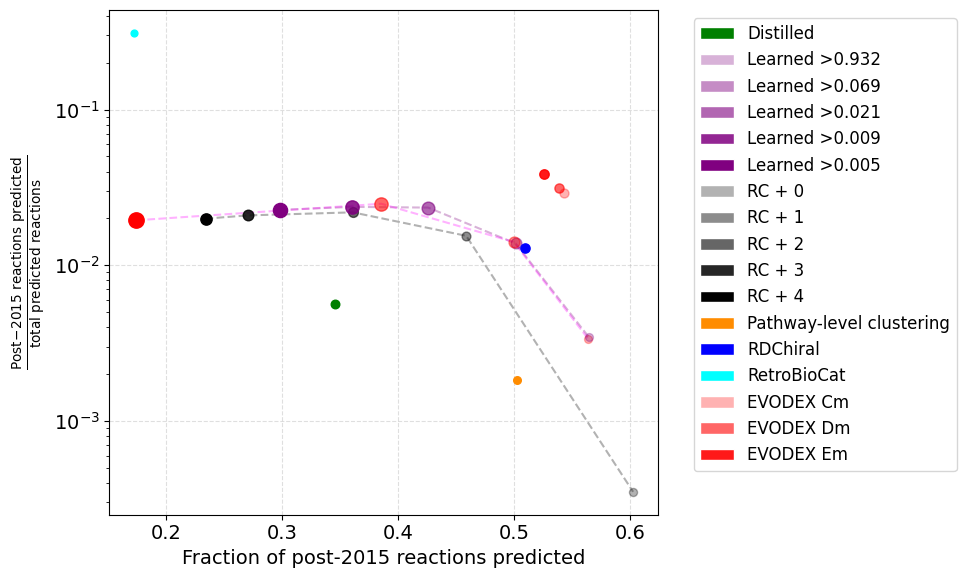

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
dot_slope = 2
dot_intercept = 24

# collect grouped points for connecting lines
mechinferred_data = []
rcr_data = []
dmo_data = []

for row in metrics.iter_rows(named=True):
    name = row["name"]
    if name not in exp_labels:
        continue

    x = row["frac_pub_rxns"]
    y = row["num_pub_rxns"] / row["num_rxns"]

    template_size = median_template_size.get(name)
    marker_size = (
        dot_slope * template_size + dot_intercept
        if template_size is not None
        else dot_intercept
    )

    if name.startswith("mechinferred_dt_") and "direct_mcsa_only" not in name:
        mechinferred_data.append((x, y))
    elif name.startswith("rc_plus_"):
        rcr_data.append((x, y))
    elif "direct_mcsa_only" in name:
        dmo_data.append((x, y))

    ax.scatter(
        x,
        y,
        color=colors[name],
        s=marker_size,
        label=exp_labels[name],
        zorder=3,
    )

# connect purple dots (mechinferred)
if mechinferred_data:
    mechinferred_data = sorted(mechinferred_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in mechinferred_data],
        [p[1] for p in mechinferred_data],
        color="purple",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

# connect black dots (rc_plus)
if rcr_data:
    rcr_data = sorted(rcr_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in rcr_data],
        [p[1] for p in rcr_data],
        color="black",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

if dmo_data:
    dmo_data = sorted(dmo_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in dmo_data],
        [p[1] for p in dmo_data],
        color="magenta",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

ax.set_xlabel(f"Fraction of post-{cutoff_date} reactions predicted")
ax.set_ylabel(
    rf"$\frac{{\mathrm{{Post\!-\!{cutoff_date}\ reactions\ predicted}}}}{{\mathrm{{total\ predicted\ reactions}}}}$"
)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_yscale("log")
plt.tight_layout()
plt.show()


In [55]:
from ergochemics.draw import draw_reaction
from IPython.display import SVG
from rdkit import Chem

def rm_hs(rxn: str) -> str:
    lhs, rhs = rxn.split('>>')
    lhs = Chem.MolToSmiles(Chem.RemoveHs(Chem.MolFromSmiles(lhs)))
    rhs = Chem.MolToSmiles(Chem.RemoveHs(Chem.MolFromSmiles(rhs)))
    return f"{lhs}>>{rhs}"

In [46]:
maps = pl.read_parquet(
    "../data/raw/mappings/mappings_known_reactions_after_2015_x_evodex_Cm_rules_before_2015.parquet"
).unique('rxn_id')

df = maps.join(other=pub, left_on='rxn_id', right_on='id', how='left', suffix='_true')
df.head()

rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id,pub_date,smarts_true
str,str,str,str,str,str,i32,str
"""8af1e81aaa4705619346c80ce56259…","""[H]OC([H])(C(=O)N([H])C([H])([…","""[H]OC([H])(C(=O)N([H])C([H])([…","""[#6]-[#16]-[#6:30](=[#8:32])-[…","""11,12,13,14,15;1,0,43>>9,10,11…","""EVODEX.2-Cm80""",2023,"""CC(=O)OC1OC(C2OC2(C)C)CC1C1CC=…"
"""41d6a5e2173fee10d600612934e62b…","""[H]Oc1c([H])c2c(c3c1C(=O)OC([H…",null,"""[#6:71]-[#8:70]-[#6](=[#8])-[#…","""12,13,14,15,16>>""","""EVODEX.2-Cm120""",2018,"""CC(=O)OC1c2c3c(cc(O)c2C(=O)OC1…"
"""d6abd77022bc8b0582e31b3741a0b3…","""[H]OC([H])([H])C1([H])OC([H])(…",null,"""[#6:3]-[#6:1](-[#8]-[#6])(-[#1…","""7,6,5,4,83,84;14,15,16,17,34,1…","""EVODEX.2-Cm190""",2016,"""CC(CCC(OC1OC(COC2OC(CO)C(O)C(O…"
"""bf7d434f6ec5976d1c137fc81deb72…","""*OC1([H])C([H])(O[H])C(*)([H])…",null,"""[#8]=[#15](-[#8])(-[#8])-[#8:1…","""12,11,10,13,14,15>>""","""EVODEX.2-Cm148""",2020,"""*OC1C(COP(=O)(O)OC2C(COP(=O)(O…"
"""8e5b6f5309bb1304fbb408800b8a63…","""[H]OC(=O)C([H])(N([H])C(=O)C([…",null,"""[#6:3]-[#6:1](=[#8:4])-[#8:14]…","""3,1,2,0,17;18,17,19,37,16,20>>""","""EVODEX.2-Cm15""",2015,"""CC(O)C(=O)NC(Cc1ccccc1)C(=O)O.…"


In [86]:
i = 0

true reaction:


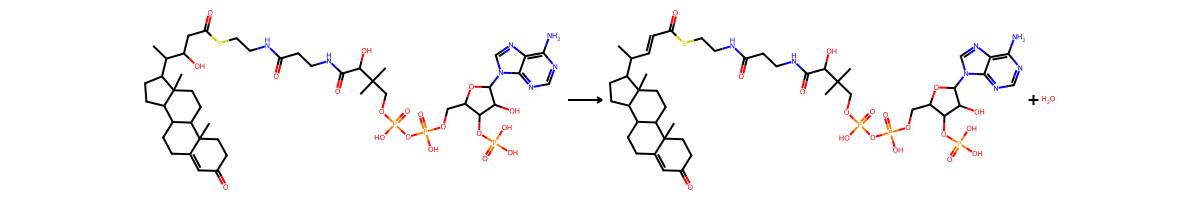

generated reaction:


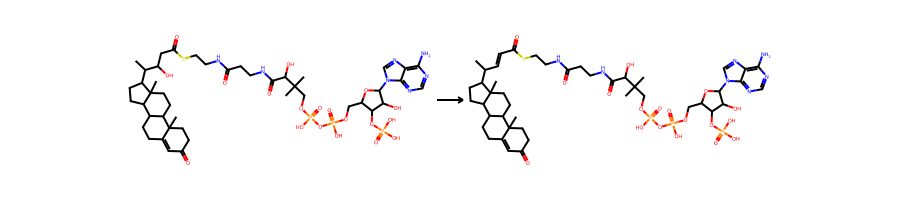

rule:


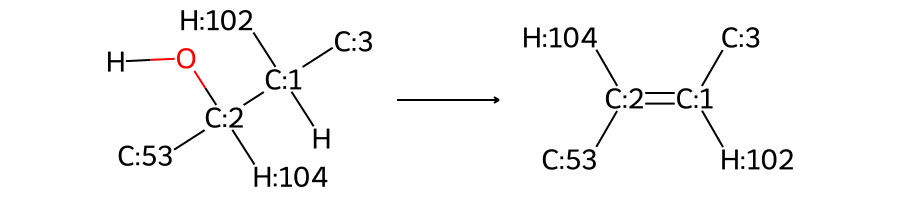

In [159]:
row = df.row(i, named=True)
true_rxn = row['smarts_true']
gen_rxn = rm_hs(row['smarts'])
rule = row['rule']

i +=1


print("true reaction:")
display(SVG(draw_reaction(true_rxn)))

print("generated reaction:")
display(SVG(draw_reaction(gen_rxn)))

print("rule:")
display(SVG(draw_reaction(rule)))

In [67]:
krs = pl.read_parquet(Path(cfg.known) / "known_reactions.parquet")
krs.head()

id,smarts,enzymes,reverse,db_ids
str,str,list[str],str,list[str]
"""e908a824c912d1e39c46de92d1f738…","""**.NC(CCC(=O)NC(CS)C(=O)NCC(=O…","[""P30109"", ""P57108"", … ""P46436""]","""3bbe8e6dca0da1c745e7678c8efebe…","[""RHEA:16438""]"
"""d86d99a8143d3be8fc861a5de5e625…","""*.*.*.*.*.*.*.*.*.*.CC(C)(COP(…","[""Q0UK48"", ""A0A0C6E0I7"", … ""A0A0C6DWS6""]","""e99fb0b75e799eba72aee21c1d04ee…","[""RHEA:51350""]"
"""2972b2db66715ba6f3d6aeaf07f31b…","""*.*.*.*.*.*.*.*.*NC(COP(=O)(O)…","[""G0REX6"", ""P0DO30"", ""A0A482N9V7""]","""5a7fffef224c65b7cd431ddc668eb2…","[""RHEA:64546""]"
"""572e4a84a946af07c9ab6fd1c0347b…","""*.*.*.*.*.*.*.*.*OP(=O)(O)OCC(…","[""Q6M083"", ""Q8U4J0"", … ""C5A6E5""]","""c4c936d8d985a457a128601b8d2769…","[""RHEA:64377""]"
"""dfe7fc761de3c213bf2b18fae4f8a5…","""*.*.*.*.*.*.*.*.CC(C)CCCC(C)CC…","[""Q6M083"", ""Q8U4J0"", … ""C5A6E5""]","""2e026380a550baa6b343604e6f5500…","[""RHEA:64369""]"


In [76]:
pub.head()

id,pub_date,smarts
str,i32,str
"""eb415024c587a81f80da9f7f236288…",2025,"""CC(N)C(=O)NC(CCC(N)=O)C(=O)O.N…"
"""3b781622ecac0cfeeb5a6934514781…",2020,"""O.O.O=C(O)CCC(=O)O.O=C=O.O=C=O…"
"""49b95c459a5c456f41087d6402ff12…",2016,"""Nc1ncnc2c1ncn2C1OC(COP(=O)(O)O…"
"""032fcec0fe7929bcf9d0a221003011…",2017,"""O.O.O=C1NC(Cc2c[nH]c3ccccc23)C…"
"""49d74533c93e4826ab213c3eaebf1f…",2017,"""C=CC(C)(C)c1[nH]c2ccccc2c1C=C1…"


In [77]:
krs.shape

(28142, 5)

In [79]:
krids = set(krs['id'].to_list())
pubids = set(pub['id'].to_list())
len(pubids - krids)

488

In [106]:
488 / 4306

0.1133302368787738